# Sprint 5 — TGAT + community-risk đã dựa vào thông tin nào?

Sprint trước đã so sánh các cấu hình bằng validation AP và chọn **TGAT +
community-risk** làm mô hình chính. Notebook này không train lại model. Nó trả
lời:

> **Mô hình dựa vào thông tin nào để đánh giá một node là đáng ngờ, và lời giải
> thích đó có đủ ổn định, đáng tin để sử dụng hay không?**

Ta dùng GNNExplainer để gán điểm cho feature và event, rồi kiểm tra lại bằng
cách tác động trực tiếp lên đầu vào và chạy model lại. Notebook chỉ trình bày
protocol và kết quả cuối.

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "artifacts" / "metrics").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Không tìm thấy project root")


ROOT = find_project_root(Path.cwd())
METRICS = ROOT / "artifacts" / "metrics"
FIGURES = ROOT / "artifacts" / "figures" / "sprint5"
RESULT_PATH = METRICS / "sprint5_explainer_final.json"
result = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
insights = result["model_insights"]
assert result["status"] == "complete_final_reader_artifact"
assert len(result["main_explanations"]) == 80
print("Đã đọc artifact cuối: 40 validation + 40 test target.")

Đã đọc artifact cuối: 40 validation + 40 test target.


## Phương pháp thí nghiệm

**Event** là một lần tương tác có hướng giữa hai node, kèm loại và thời gian.
Hai node có thể có nhiều event. **Feature** gồm 17 giá trị ẩn danh F01–F17, 17
cờ báo thiếu dữ liệu và community-risk.

GNNExplainer tạo một **mask**, có thể hiểu như điểm giữ lại cho từng event hoặc
feature. Mọi điểm bắt đầu ngang nhau ở 0,5 rồi được tối ưu trong 50 epoch; trọng
số TGAT được đóng băng.

Điểm cao không tự động là đáp án đúng. Vì vậy ta kiểm tra bằng bốn bước:

1. đưa lần lượt từng feature về nền (0 cho 34 đầu vào gốc/cờ thiếu;
   global train prior cho community-risk);
2. bỏ lần lượt từng event;
3. chỉ giữ rồi bỏ nhóm event đứng đầu;
4. so với quy tắc ngẫu nhiên, nhiều liên kết và event gần nhất.

## 1. Model nhìn thấy bao nhiêu event?

TGAT lấy một hop và tối đa 15 event, nhưng 15 chỉ là giới hạn trên. Neighborhood
thật của phần lớn target nhỏ hơn nhiều.

,Tổng target,Chỉ có 1 event,Có nhiều nhất 3 event,Có thể xếp hạng (từ 2 event),Nhiều event nhất
0,80,41,68,39,8


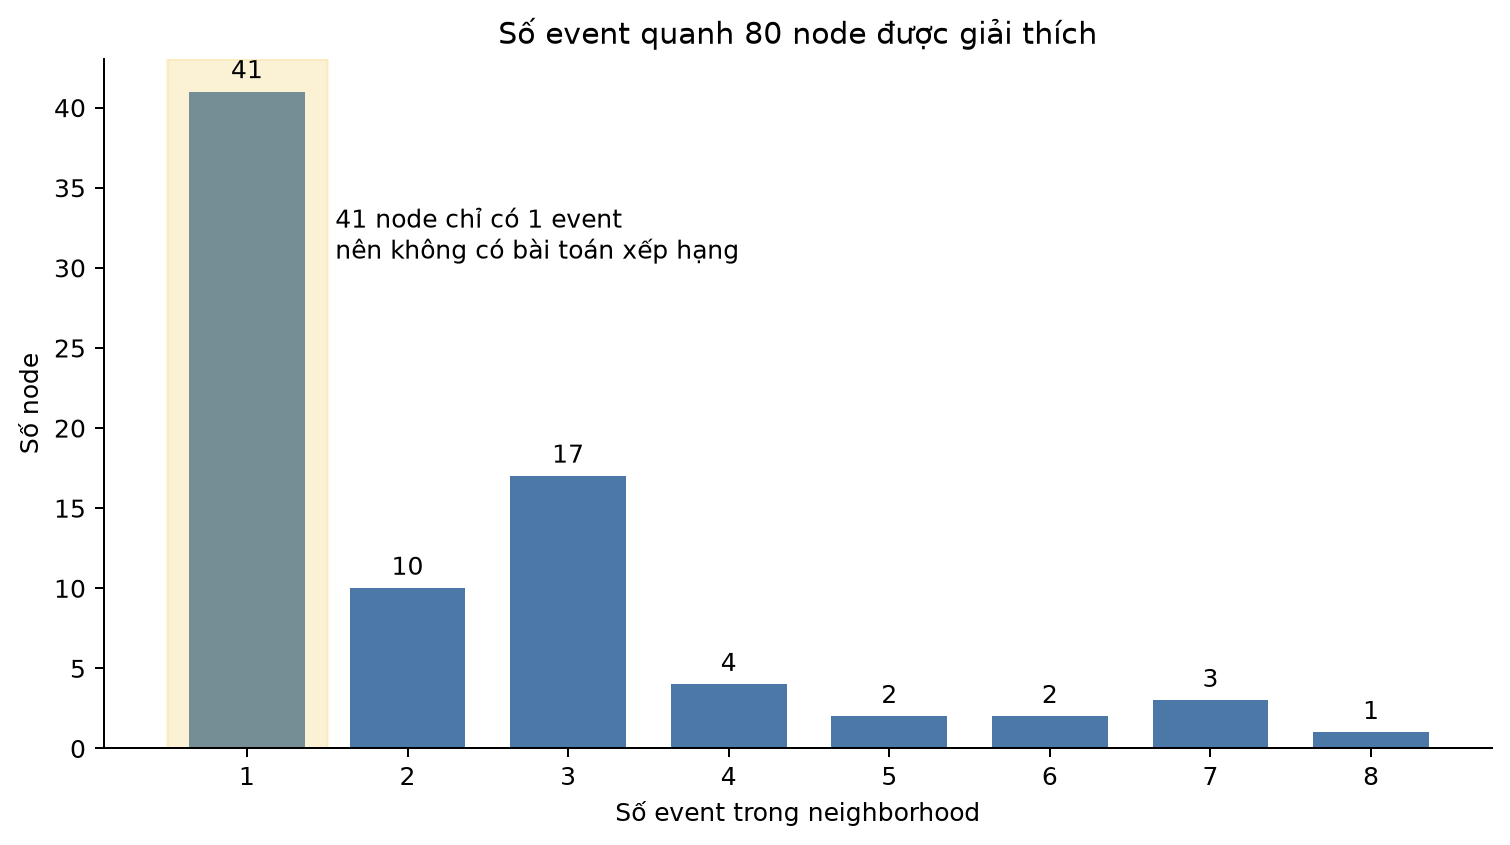

In [2]:
event_count = result["summaries"]["all"]["event_count"]
display(pd.DataFrame([{
    "Tổng target": 80,
    "Chỉ có 1 event": event_count["one_event_count"],
    "Có nhiều nhất 3 event": event_count["at_most_three_count"],
    "Có thể xếp hạng (từ 2 event)": event_count["meaningful_ranking_count"],
    "Nhiều event nhất": event_count["max"],
}]))
display(Image(filename=str(FIGURES / "01_neighborhood_size.png"), width=820))

41/80 target chỉ có một event và 68/80 có nhiều nhất ba event. Vì vậy nhiều
trường hợp không tạo thành một bài toán chọn graph con khó: đôi khi phải giữ
gần như toàn bộ neighborhood nhỏ.

## 2. GNNExplainer chọn feature nào?

DGraphFin không công bố ý nghĩa nghiệp vụ của F01–F17, nên ta giữ đúng tên ẩn
danh. Top-5 là năm feature có điểm cao nhất cho một target. Bảng so GNNExplainer
với phép đưa riêng từng feature về mức nền.

,Feature,GNNExplainer: vào top-5,Đưa riêng feature về nền: vào top-5
0,F03,46/80,40/80
1,F07,42/80,41/80
2,F11,41/80,39/80
3,F10,38/80,39/80
4,F17,34/80,39/80
5,F12,24/80,26/80
6,F02,23/80,18/80
7,F05,22/80,37/80
8,community-risk,17/80,18/80


,Tập/nhóm,Top theo GNNExplainer,Top theo đưa từng feature về nền
0,Validation,"F03 (22/40), F07 (21/40), F10 (20/40), F11 (20...","F07 (21/40), F03 (20/40), F10 (20/40), F17 (20..."
1,Test,"F03 (24/40), F07 (21/40), F11 (21/40), F10 (18...","F03 (20/40), F07 (20/40), F11 (20/40), F05 (19..."
2,High-score fraud,"F17 (20/20), F11 (18/20), F05 (16/20), F02 (15...","F17 (20/20), F05 (19/20), F11 (19/20), F15 (16..."
3,High-score normal,"F11 (20/20), F17 (14/20), F06 (11/20), F01 (7/...","F11 (20/20), F17 (19/20), F05 (18/20), F15 (17..."
4,Low-score fraud,"F03 (20/20), F07 (20/20), F10 (18/20), F08 (10...","F03 (20/20), F07 (20/20), F10 (19/20), F08 (12..."
5,Low-score normal control,"F03 (20/20), F07 (20/20), F10 (18/20), F12 (15...","F03 (20/20), F07 (20/20), F10 (17/20), F12 (15..."


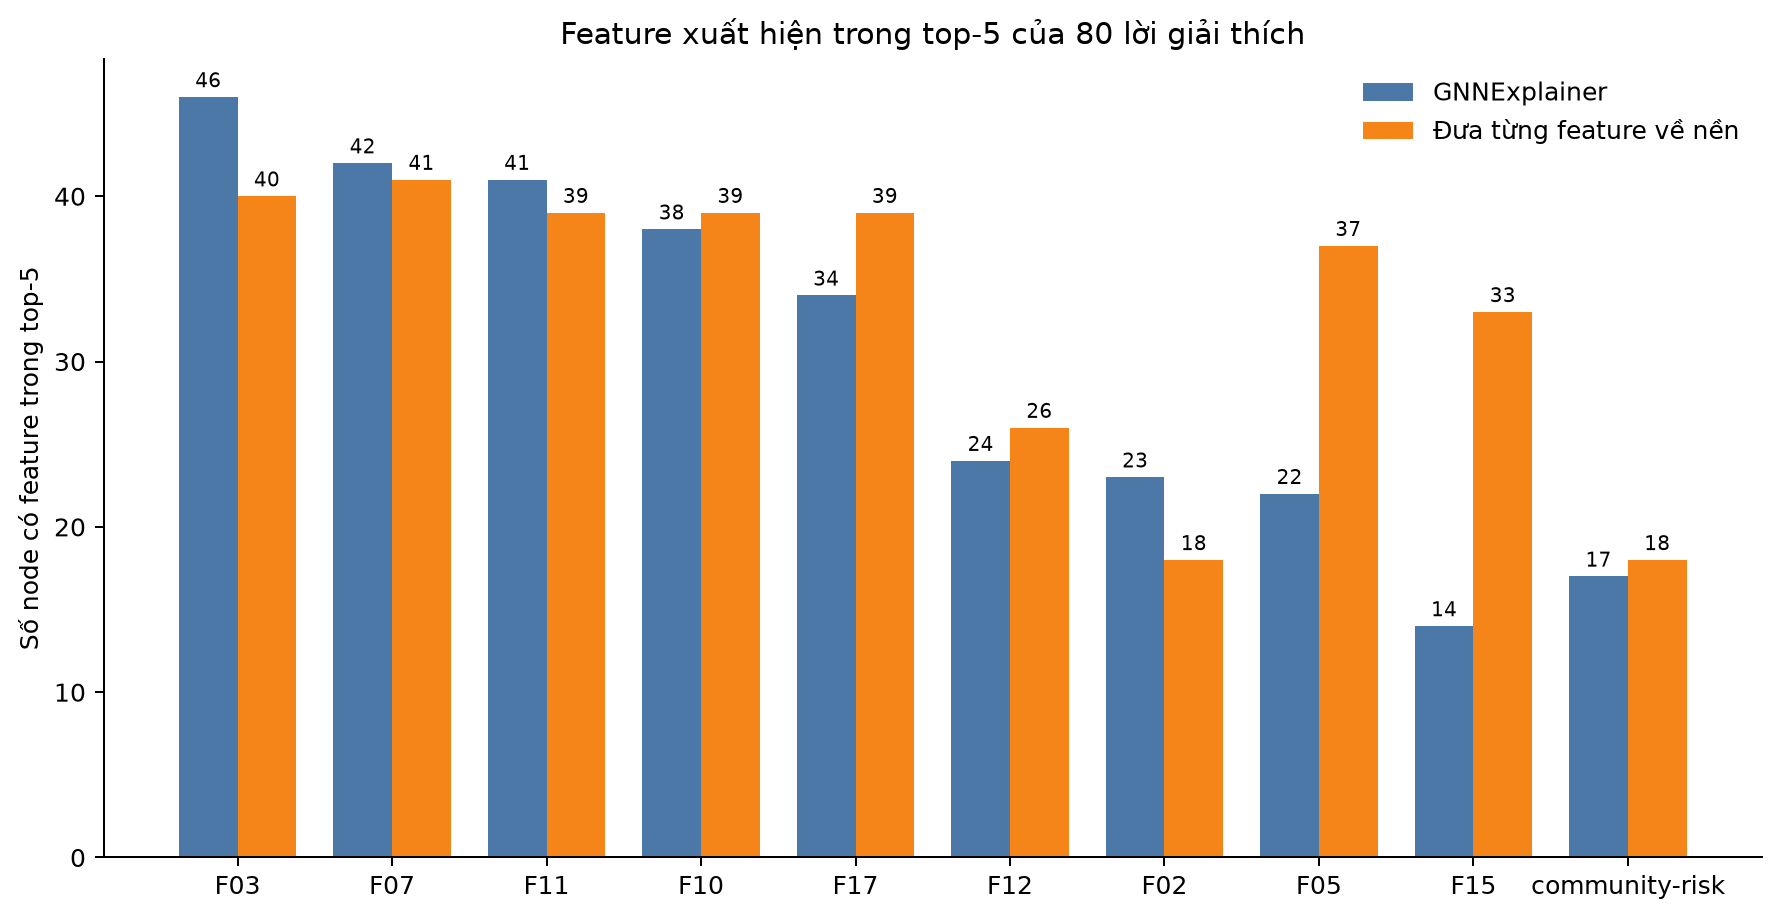

In [3]:
fp = insights["feature_patterns"]["all"]
direct = {x["feature_name"]: x["top_5_count"]
          for x in fp["direct_ablation_top_5_frequency"]}
rows = fp["gnnexplainer_top_5_frequency"][:8]
if not any(x["feature_name"] == "community-risk" for x in rows):
    rows = rows + [next(x for x in fp["gnnexplainer_top_5_frequency"]
                        if x["feature_name"] == "community-risk")]
display(pd.DataFrame([{
    "Feature": x["feature_name"],
    "GNNExplainer: vào top-5": f'{x["top_5_count"]}/80',
    "Đưa riêng feature về nền: vào top-5": f'{direct.get(x["feature_name"], 0)}/80',
} for x in rows]))
group_names = [
    ("Validation", "validation"),
    ("Test", "test"),
    ("High-score fraud", "cohort:high_score_fraud"),
    ("High-score normal", "cohort:high_score_normal"),
    ("Low-score fraud", "cohort:low_score_fraud"),
    ("Low-score normal control", "cohort:low_score_normal_control"),
]
display(pd.DataFrame([{
    "Tập/nhóm": label,
    "Top theo GNNExplainer": ", ".join(
        f'{x["feature_name"]} ({x["top_5_count"]}/{insights["feature_patterns"][key]["target_count"]})'
        for x in insights["feature_patterns"][key]["gnnexplainer_top_5_frequency"][:5]
    ),
    "Top theo đưa từng feature về nền": ", ".join(
        f'{x["feature_name"]} ({x["top_5_count"]}/{insights["feature_patterns"][key]["target_count"]})'
        for x in insights["feature_patterns"][key]["direct_ablation_top_5_frequency"][:5]
    ),
} for label, key in group_names]))
display(Image(filename=str(FIGURES / "02_feature_patterns.png"), width=900))

Hai cách cùng nhấn mạnh lõi F03, F07, F10, F11 và F17. Ở cấp từng node, thứ tự
chỉ đồng thuận vừa phải: Spearman trung vị 0,467 và top-5 Jaccard trung vị
0,667. Vì thế nên đọc các feature lặp lại như xu hướng ở cấp nhóm, không khẳng
định chắc khoảng cách hạng nhỏ tại một node.

## 3. Community-risk có vai trò ở đâu?

Ta không chỉ đọc mask. Ta thay riêng community-risk của target bằng global
train prior, giữ graph và 34 feature còn lại, rồi chạy model lại. Logit đầy đủ
trừ logit sau thay thế dương nghĩa là community-risk đang đẩy dự đoán về fraud.

,Nhóm,Community-risk vào top-5,Hạng trung vị,Logit đổi trung bình khi đưa về nền
0,High-score fraud,11/20,5.0,0.257
1,High-score normal,3/20,15.5,0.040
2,Low-score fraud,2/20,14.0,-0.039
3,Low-score normal control,1/20,12.0,0.031


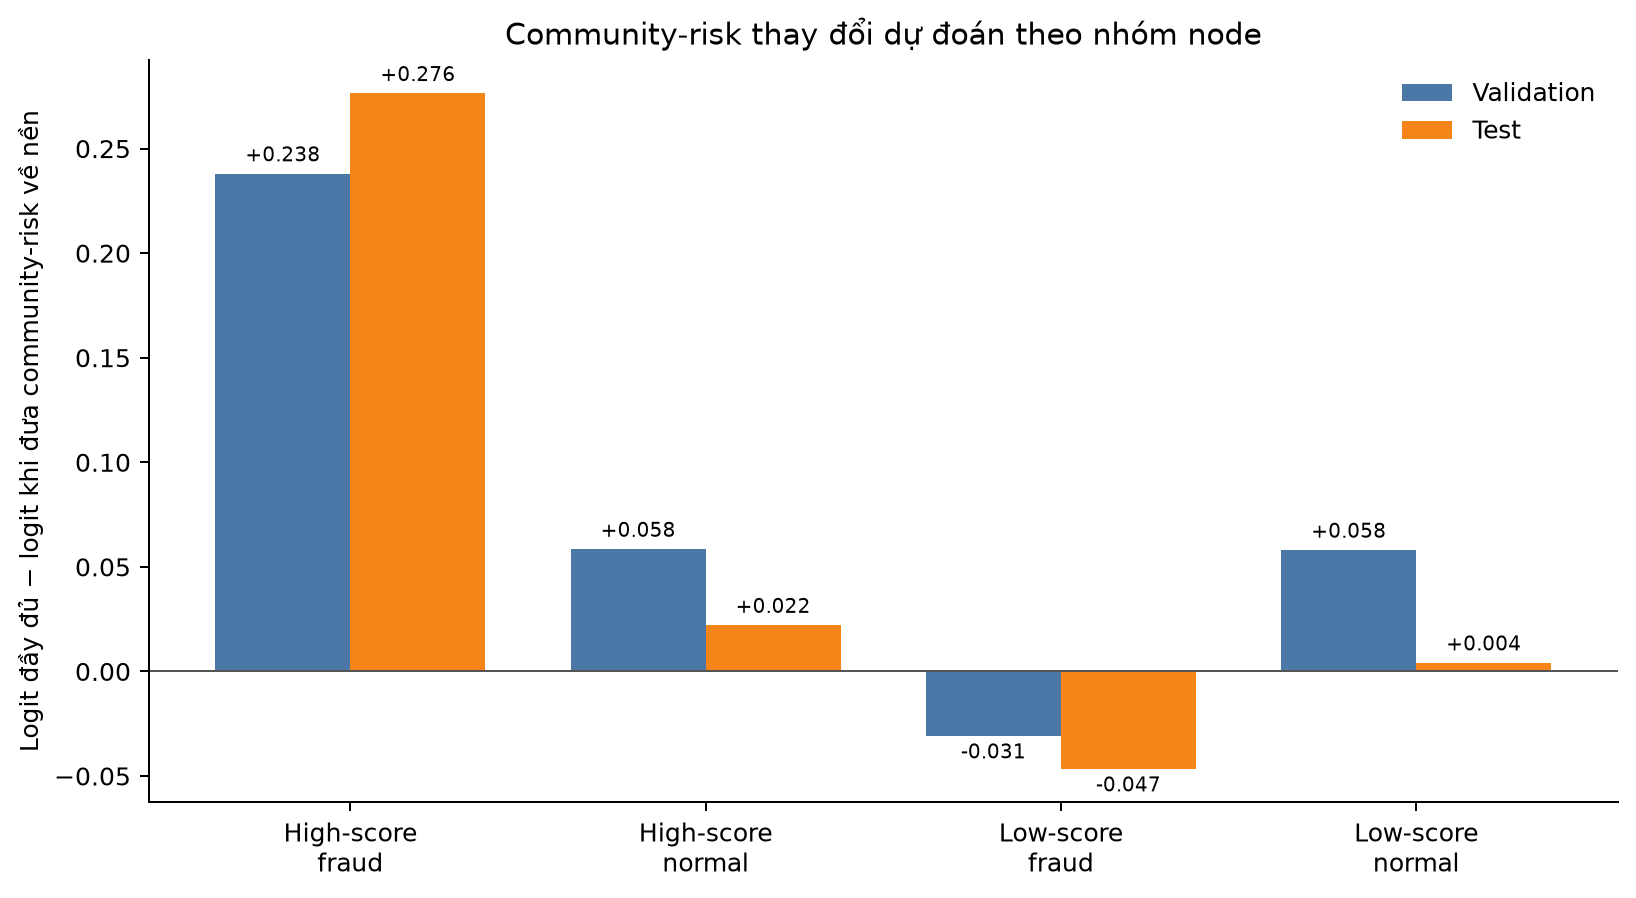

In [4]:
risk = insights["community_risk"]
groups = [
    ("High-score fraud", "cohort:high_score_fraud"),
    ("High-score normal", "cohort:high_score_normal"),
    ("Low-score fraud", "cohort:low_score_fraud"),
    ("Low-score normal control", "cohort:low_score_normal_control"),
]
display(pd.DataFrame([{
    "Nhóm": label,
    "Community-risk vào top-5": f'{risk[key]["gnnexplainer_top_5_count"]}/20',
    "Hạng trung vị": risk[key]["gnnexplainer_median_rank"],
    "Logit đổi trung bình khi đưa về nền": risk[key]["mean_logit_delta"],
} for label, key in groups]).round(3))
display(Image(filename=str(FIGURES / "03_community_risk_counterfactual.png"), width=900))

Community-risk vào top-5 ở 17/80 target, nhưng 11 trường hợp nằm trong nhóm
high-score fraud. Ở nhóm này, đưa community-risk về nền làm logit giảm trung
bình 0,257. Nó là tín hiệu quan trọng cho một phần high-score fraud, không phải
feature thống trị ở mọi node.

## 4. GNNExplainer chọn event nào?

Chỉ 39 target có từ hai event để xếp hạng. Ta kiểm tra event đứng đầu bằng cách
bỏ lần lượt từng event và tìm event làm target-class score thay đổi mạnh nhất.
Phép bỏ từng event là một mốc kiểm tra trực tiếp, không phải ground truth tuyệt
đối vì nhiều event có thể tương tác.

In [5]:
table = []
for split, label in [("validation", "Validation"), ("test", "Test"), ("all", "Gộp")]:
    s = result["summaries"][split]
    table.append({
        "Tập": label,
        "Node có từ 2 event": s["event_count"]["meaningful_ranking_count"],
        "Top GNNExplainer trùng phép bỏ từng event": s["edge"]["top_matches_leave_one_out_count"],
        "Event gần nhất trùng phép bỏ từng event": s["edge"]["recency_matches_leave_one_out_count"],
    })
display(pd.DataFrame(table))

ep = insights["event_patterns"]
display(pd.DataFrame([{
    "Tổng sampled event": ep["all_sampled_event_count"],
    "Top GNNExplainer là event gần nhất": f'{ep["gnnexplainer_top_is_most_recent_count"]}/39',
    "Event nằm cùng community target": (
        f'{insights["community_relation"]["all_sampled_events_internal_count"]}/'
        f'{insights["community_relation"]["all_sampled_event_count"]}'
    ),
}]))

,Tập,Node có từ 2 event,Top GNNExplainer trùng phép bỏ từng event,Event gần nhất trùng phép bỏ từng event
0,Validation,17,11,6
1,Test,22,8,10
2,Gộp,39,19,16


,Tổng sampled event,Top GNNExplainer là event gần nhất,Event nằm cùng community target
0,179,20/39,179/179


Trên validation, GNNExplainer trùng phép bỏ từng event 11/17, tốt hơn chọn event
gần nhất 6/17. Trên test, GNNExplainer chỉ đạt 8/22, thấp hơn event gần nhất
10/22. Event loại 4, 5 và 6 phổ biến cả trong toàn bộ neighborhood lẫn nhóm đứng
đầu, nên chưa thể nói model ưu tiên riêng một loại sau khi xét tần suất nền.

Toàn bộ 179 sampled event đều nằm cùng Leiden community với target. Tỷ lệ này
không chứng minh GNNExplainer thích event nội bộ, vì không có event ngoài
community trong tập quan sát để so.

## 5. Lời giải thích có đủ đáng tin không?

Với event, ta thử top-1, top-2, ... theo từng cách xếp. Chọn nhóm ngắn nhất thỏa
cả hai phép:

1. chỉ giữ nhóm đó: target-class score lệch không quá 0,05 so với graph đầy đủ;
2. bỏ nhóm đó: target-class score giảm.

“Ngẫu nhiên” chỉ là xáo thứ tự event bằng seed cố định; model vẫn là TGAT đã train.

,Cách xếp event,Node đạt giữ/bỏ
0,GNNExplainer,73
1,Ngẫu nhiên,70
2,Nhiều liên kết,71
3,Event gần nhất,70


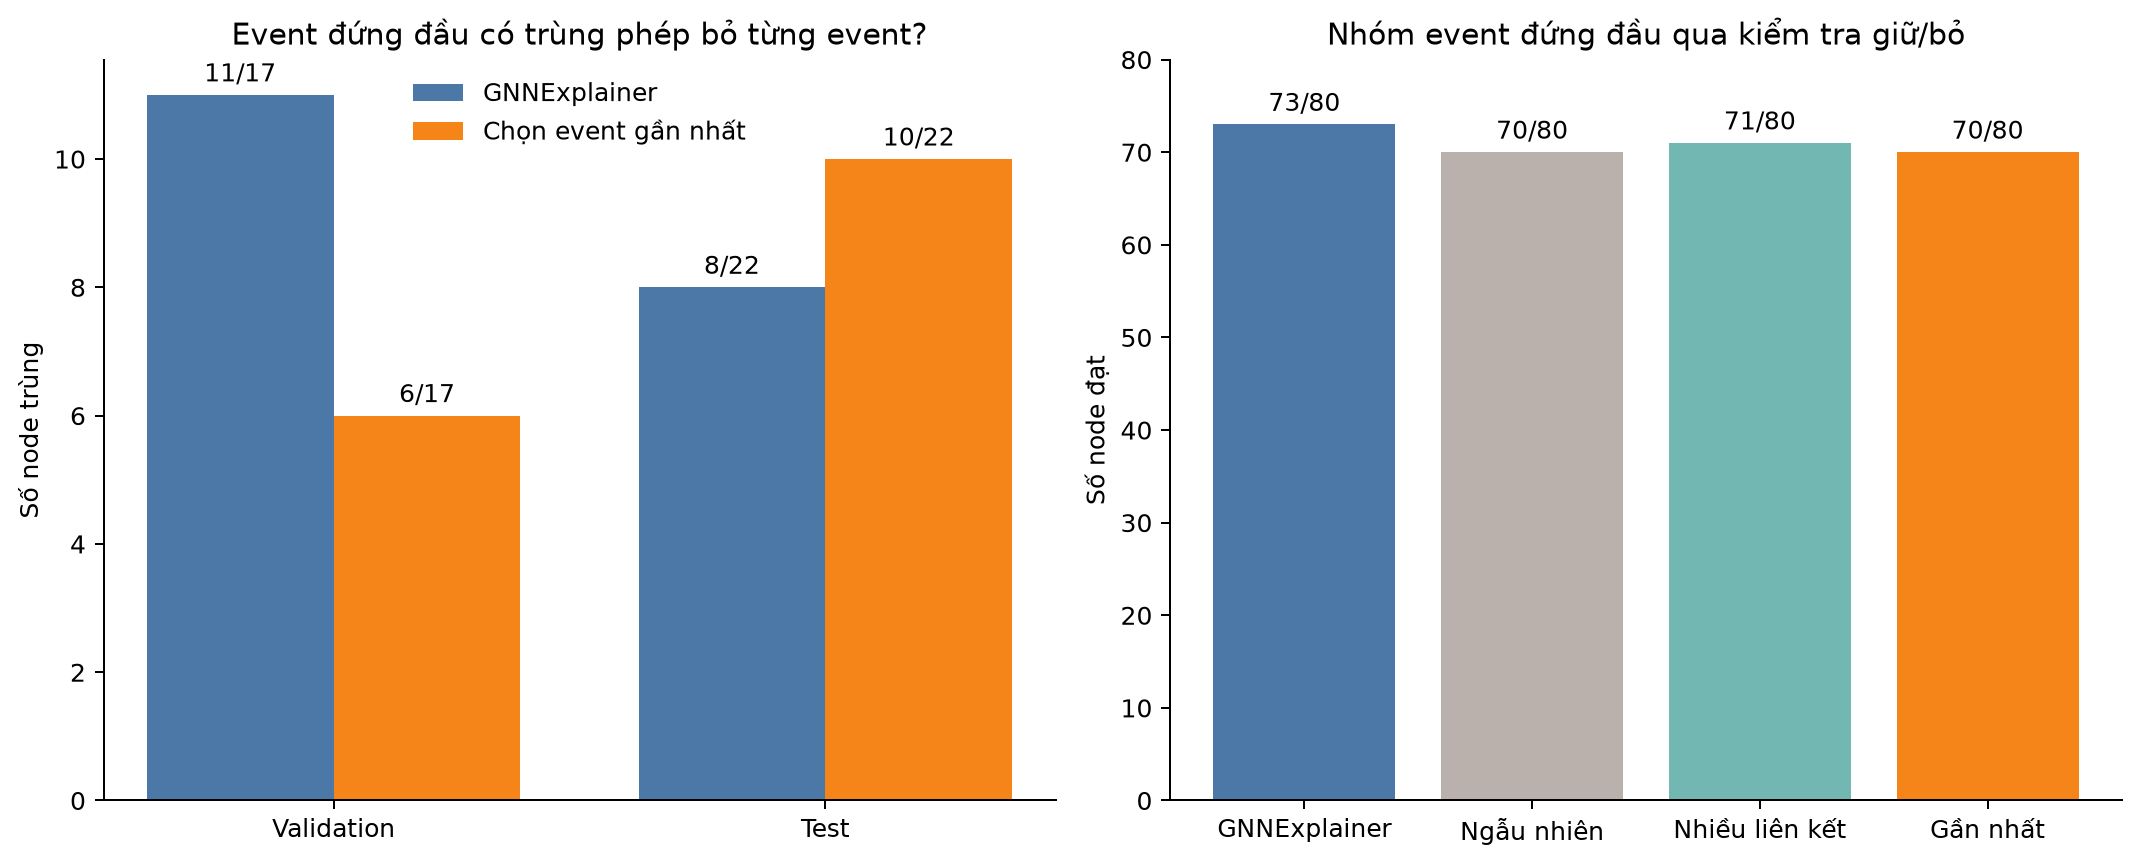

In [6]:
s = result["summaries"]["all"]
display(pd.DataFrame([
    {"Cách xếp event": "GNNExplainer", "Node đạt giữ/bỏ": s["edge"]["fidelity_pass_count"]},
    {"Cách xếp event": "Ngẫu nhiên", "Node đạt giữ/bỏ": s["baselines"]["random"]["adaptive_fidelity_pass_count"]},
    {"Cách xếp event": "Nhiều liên kết", "Node đạt giữ/bỏ": s["baselines"]["degree"]["adaptive_fidelity_pass_count"]},
    {"Cách xếp event": "Event gần nhất", "Node đạt giữ/bỏ": s["baselines"]["recency"]["adaptive_fidelity_pass_count"]},
]))
display(Image(filename=str(FIGURES / "04_event_explanation_checks.png"), width=1050))

GNNExplainer đạt 73/80 nhưng ba baseline cũng đạt 70–71/80. Trung vị sparsity
của các case đạt là 0,0: trong ít nhất một nửa số case, cả bốn cách phải giữ
toàn bộ neighborhood. Do đó 73/80 không có nghĩa GNNExplainer đã tìm được graph
con gọn hơn rõ ràng.

In [7]:
control = result["negative_control"]["aggregate"]
stability = result["cross_model_stability"]["aggregate"]
display(pd.DataFrame([{
    "Feature top-5 qua giữ/bỏ": f'{s["feature"]["fidelity_pass_count"]}/80',
    "Feature Spearman với phép đưa từng feature về nền": s["feature"]["median_rank_spearman"],
    "Feature Spearman qua checkpoint": stability["median_feature_spearman"],
    "Negative control: event Spearman": control["median_edge_rank_spearman"],
    "Negative control: exact ranking match": control["exact_ranking_match_count"],
}]).round(3))

,Feature top-5 qua giữ/bỏ,Feature Spearman với phép đưa từng feature về nền,Feature Spearman qua checkpoint,Negative control: event Spearman,Negative control: exact ranking match
0,54/80,0.467,0.801,0.004,0


Negative control dùng cùng kiến trúc nhưng trọng số chưa train. Qua 15 phép so,
Spearman event trung vị 0,004, top-3 Jaccard 0 và không có ranking trùng hoàn
toàn. Điều này cho thấy ranking không chỉ do kiến trúc tự sinh ra. Tuy nhiên,
nó không thay đổi hạn chế chính: trên test, GNNExplainer chưa hơn event gần nhất.

## 6. Kết luận

**GNNExplainer cho biết gì:** F03, F07, F10, F11 và F17 lặp lại nhiều trong
feature top-5; community-risk quan trọng rõ nhất ở một phần high-score fraud.
Phần graph quanh target thường rất nhỏ và chỉ có event nội bộ community.

**Mức độ tin cậy:** feature explanation tương đối ổn định qua ba checkpoint và
đồng thuận vừa phải với phép đưa từng feature về nền, nên phù hợp để đọc như xu
hướng ở cấp nhóm. Event explanation chưa đủ mạnh: GNNExplainer đạt 73/80 nhưng
baseline cũng đạt 70–71/80, thường phải giữ toàn bộ neighborhood và không hơn
event gần nhất trên test. Sprint 5 vì vậy **không đề xuất graph con nào cho
người điều tra**.

Negative control cho thấy ranking có thay đổi theo trọng số TGAT đã học, nhưng
không chứng minh thứ hạng event là chính xác. Kết luận chỉ áp dụng cho model,
neighborhood một hop và 80 target hiện tại.

**Hướng cải tiến:**

1. kiểm tra thời gian và cấu trúc graph bằng can thiệp trực tiếp; GNNExplainer
   chỉ dùng để minh họa phụ;
2. giữ 80 target cũ và bổ sung nhóm target có nhiều event theo các mức
   neighborhood đã định trước;
3. so đường cong giữ/bỏ ở cùng top-1, top-2, top-3, ... thay vì chỉ dùng một
   ngưỡng đạt;
4. kiểm tra thêm tác động khi bỏ từng cặp event;
5. chỉ giải thích graph hai hop sau khi đã train và đánh giá một TGAT hai hop
   tương ứng.

## Artifact dùng trong notebook

- artifacts/metrics/sprint5_explainer_final.json
- artifacts/metrics/sprint5_explanations_final.npz
- artifacts/metrics/sprint5_model_insights_final.json
- artifacts/metrics/sprint5_explanation_final.csv
- bốn hình trong artifacts/figures/sprint5/